# EDA – TESS Dataset

Exploračná analýza TESS (Toronto Emotional Speech Set) datasetu.

- Počet vzoriek a distribúcia labels
- Vizualizácia MFCC a spektrogramov
- Audio charakteristiky

In [4]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Pridaj projekt root
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import Config

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Načítaj metadata

In [5]:
metadata_path = Config.TESS_PROCESSED_PATH / "metadata.csv"
df = pd.read_csv(metadata_path)

print(f"Celkom vzoriek: {len(df)}")
print(f"\nStĺpce: {df.columns.tolist()}")
print(f"\nPrvých 5 riadkov:")
print(df.head())
print(f"\nInfo o datasete:")
print(df.info())

Celkom vzoriek: 4800

Stĺpce: ['file_id', 'emotion', 'label', 'mfcc_path', 'spec_path']

Prvých 5 riadkov:
          file_id emotion  label  \
0  OAF_back_angry   angry      1   
1   OAF_bar_angry   angry      1   
2  OAF_base_angry   angry      1   
3  OAF_bath_angry   angry      1   
4  OAF_bean_angry   angry      1   

                                           mfcc_path  \
0  data\processed\tess\features\OAF_back_angry_mf...   
1  data\processed\tess\features\OAF_bar_angry_mfc...   
2  data\processed\tess\features\OAF_base_angry_mf...   
3  data\processed\tess\features\OAF_bath_angry_mf...   
4  data\processed\tess\features\OAF_bean_angry_mf...   

                                           spec_path  
0  data\processed\tess\spectrograms\OAF_back_angr...  
1  data\processed\tess\spectrograms\OAF_bar_angry...  
2  data\processed\tess\spectrograms\OAF_base_angr...  
3  data\processed\tess\spectrograms\OAF_bath_angr...  
4  data\processed\tess\spectrograms\OAF_bean_angr...  

Info o d

## 2. Distribúcia labels

Distribúcia labels:
label
0    1600
1    3200
Name: count, dtype: int64

Procenta:
label
0    33.333333
1    66.666667
Name: proportion, dtype: float64


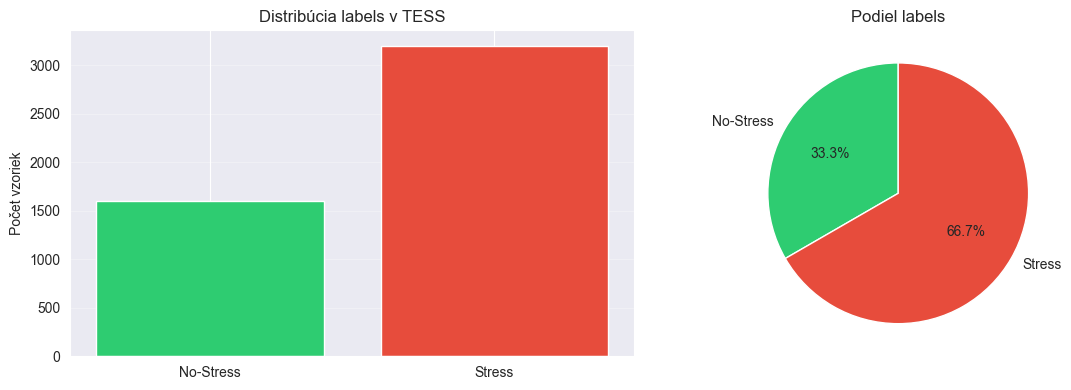

In [6]:
# Počet vzoriek pre každý label
label_counts = df['label'].value_counts().sort_index()
print("Distribúcia labels:")
print(label_counts)
print(f"\nProcenta:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
label_names = {0: 'No-Stress', 1: 'Stress'}
colors = ['#2ecc71', '#e74c3c']
axes[0].bar([label_names[i] for i in label_counts.index], label_counts.values, color=colors)
axes[0].set_ylabel('Počet vzoriek')
axes[0].set_title('Distribúcia labels v TESS')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(label_counts.values, labels=[label_names[i] for i in label_counts.index],
             autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Podiel labels')

plt.tight_layout()
plt.show()

## 3. Emócie v datasete

Distribúcia emócií:
emotion
angry      800
disgust    800
fear       800
neutral    800
ps         800
sad        800
Name: count, dtype: int64


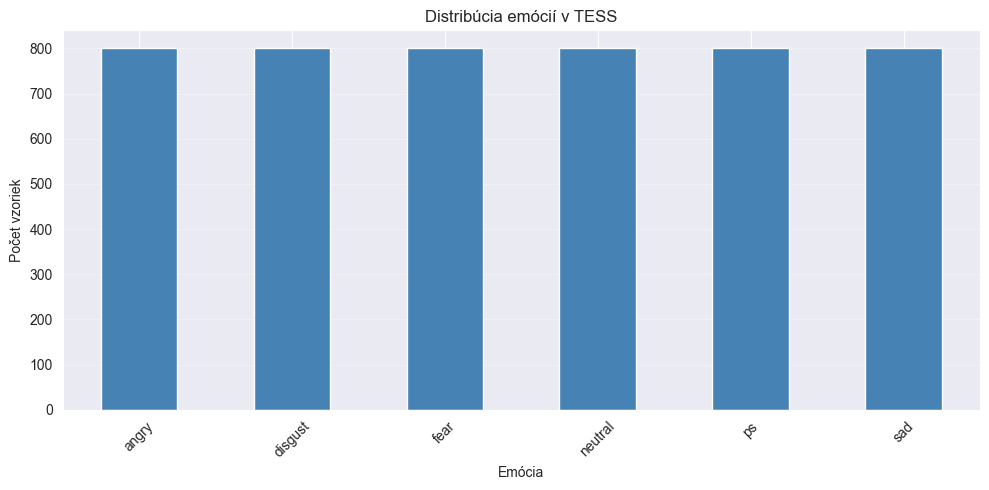

In [7]:
# Počet vzoriek pre každú emóciu
emotion_counts = df['emotion'].value_counts()
print("Distribúcia emócií:")
print(emotion_counts)

# Vizualizácia
fig, ax = plt.subplots(figsize=(10, 5))
emotion_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Počet vzoriek')
ax.set_xlabel('Emócia')
ax.set_title('Distribúcia emócií v TESS')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Vizualizácia MFCC a spektrogramu

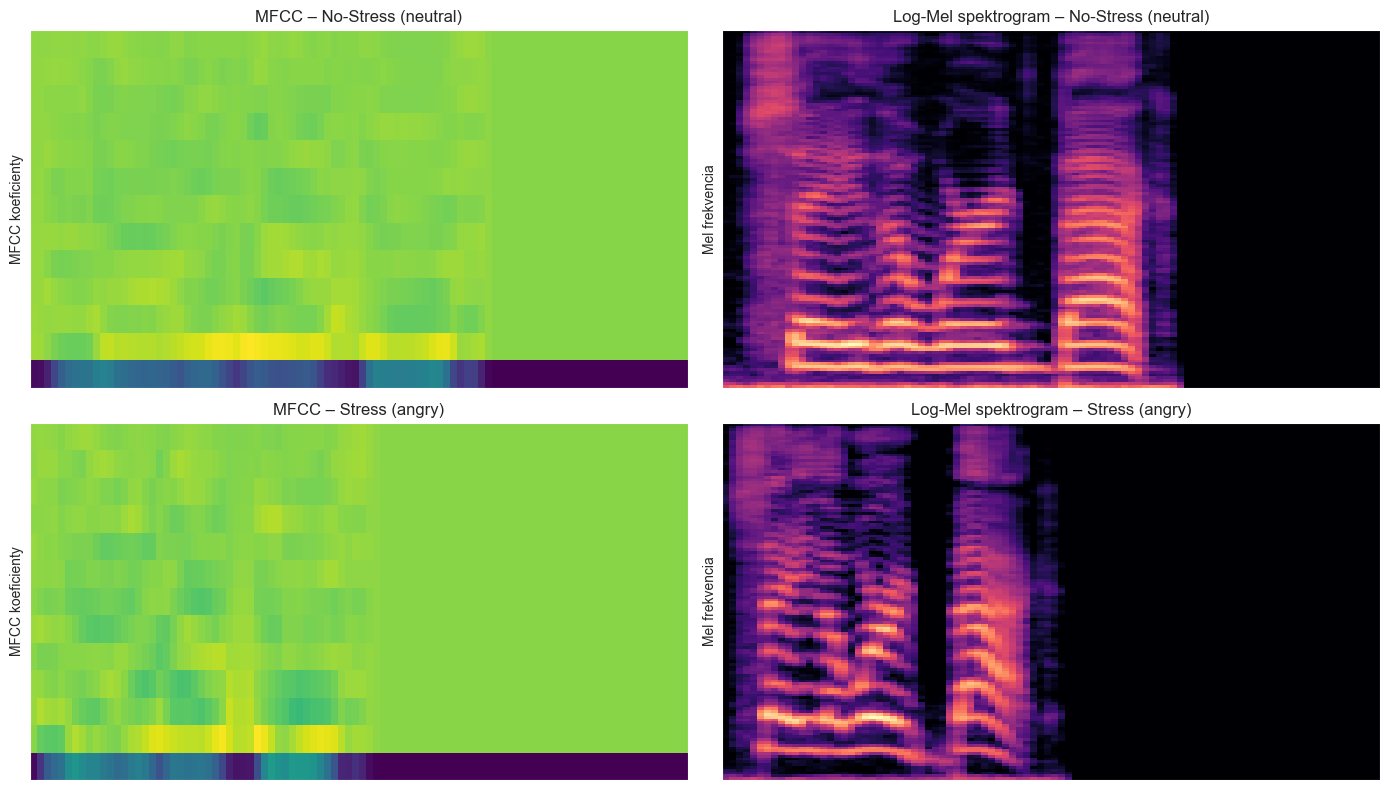

No-Stress príklad: neutral (file_id: OAF_back_neutral)
Stress príklad: angry (file_id: OAF_back_angry)


In [8]:
import librosa.display

# Vyber prvú vzorku z každého labelu
no_stress_sample = df[df['label'] == 0].iloc[0]
stress_sample = df[df['label'] == 1].iloc[0]

# Načítaj a zobrazi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (sample, row_idx) in enumerate([(no_stress_sample, 0), (stress_sample, 1)]):
    # MFCC
    mfcc_path = Config.ROOT_DIR / sample['mfcc_path']
    mfcc = np.load(mfcc_path)
    
    librosa.display.specshow(mfcc, ax=axes[idx, 0], cmap='viridis')
    axes[idx, 0].set_title(f"MFCC – {'No-Stress' if sample['label'] == 0 else 'Stress'} ({sample['emotion']})")
    axes[idx, 0].set_ylabel('MFCC koeficienty')
    
    # Log-Mel spektrogram
    spec_path = Config.ROOT_DIR / sample['spec_path']
    spec = np.load(spec_path)
    
    librosa.display.specshow(spec, ax=axes[idx, 1], cmap='magma', sr=Config.SAMPLE_RATE)
    axes[idx, 1].set_title(f"Log-Mel spektrogram – {'No-Stress' if sample['label'] == 0 else 'Stress'} ({sample['emotion']})")
    axes[idx, 1].set_ylabel('Mel frekvencia')

plt.tight_layout()
plt.show()

print(f"No-Stress príklad: {no_stress_sample['emotion']} (file_id: {no_stress_sample['file_id']})")
print(f"Stress príklad: {stress_sample['emotion']} (file_id: {stress_sample['file_id']})")

## 5. Štatistika veľkostí features

MFCC time-frames (počet vzoriek): 4800
  Priemer: 94.0
  Min: 94
  Max: 94

Log-Mel spektrogram time-frames:
  Priemer: 94.0
  Min: 94
  Max: 94


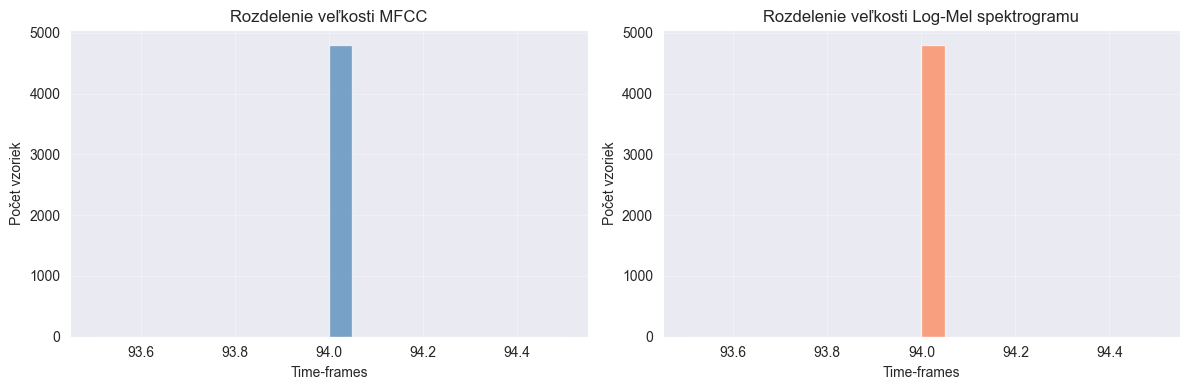

In [9]:
# Analýza rozmerov MFCC a spektrogramov
mfcc_shapes = []
spec_shapes = []

for idx, row in df.iterrows():
    mfcc = np.load(Config.ROOT_DIR / row['mfcc_path'])
    spec = np.load(Config.ROOT_DIR / row['spec_path'])
    mfcc_shapes.append(mfcc.shape[1])  # Počet time-frameov
    spec_shapes.append(spec.shape[1])

print(f"MFCC time-frames (počet vzoriek): {len(mfcc_shapes)}")
print(f"  Priemer: {np.mean(mfcc_shapes):.1f}")
print(f"  Min: {np.min(mfcc_shapes)}")
print(f"  Max: {np.max(mfcc_shapes)}")

print(f"\nLog-Mel spektrogram time-frames:")
print(f"  Priemer: {np.mean(spec_shapes):.1f}")
print(f"  Min: {np.min(spec_shapes)}")
print(f"  Max: {np.max(spec_shapes)}")

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mfcc_shapes, bins=20, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Time-frames')
axes[0].set_ylabel('Počet vzoriek')
axes[0].set_title('Rozdelenie veľkosti MFCC')
axes[0].grid(alpha=0.3)

axes[1].hist(spec_shapes, bins=20, color='coral', alpha=0.7)
axes[1].set_xlabel('Time-frames')
axes[1].set_ylabel('Počet vzoriek')
axes[1].set_title('Rozdelenie veľkosti Log-Mel spektrogramu')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()